In [1]:
import numpy as np
import pandas as  pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("student_data_clean.csv")
df.head()

,Student_ID,Name,Age,Gender,Department,Semester,CGPA,Attendance_Rate,Scholarship,Admission_Date,Midterm_Marks,Final_Marks,City,Study_Hours_Per_Day,Fees_Paid
0,1001,Student_0,24,Other,Math,3,NaN,61.0,False,2021-09-11,26,33,Multan,10,NaN
1,1002,Student_1,21,Female,EE,1,3.94,98.0,False,2020-01-26,0,39,Lahore,5,Installment
2,1003,Student_2,22,Other,EE,5,2.44,66.0,False,2022-08-14,20,46,Faisalabad,7,Full
3,1004,Student_3,24,Male,EE,4,3.47,91.0,False,2021-02-24,19,14,Faisalabad,8,Full
4,1005,Student_4,20,Male,CS,2,3.53,79.0,False,2021-10-24,12,10,Karachi,3,Installment


In [3]:
df.isnull().sum()

Student_ID              0
Name                    0
Age                     0
Gender                  0
Department              0
Semester                0
CGPA                   51
Attendance_Rate        31
Scholarship             0
Admission_Date          0
Midterm_Marks           0
Final_Marks             0
City                    0
Study_Hours_Per_Day     0
Fees_Paid              22
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(30)

In [5]:
df.describe()

,Student_ID,Age,Semester,CGPA,Attendance_Rate,Midterm_Marks,Final_Marks,Study_Hours_Per_Day
count,1030.000000,1030.000000,1030.000000,979.000000,999.000000,1030.000000,1030.000000,1030.000000
mean,1486.373786,20.971845,4.448544,3.046558,74.733734,14.845631,24.875728,6.062136
std,296.048992,1.996154,2.270094,0.574487,14.213981,8.877224,14.492520,3.149348
min,1001.000000,18.000000,1.000000,2.000000,50.000000,0.000000,0.000000,1.000000
25%,1228.250000,19.000000,3.000000,2.560000,63.000000,7.000000,12.000000,3.000000
50%,1485.500000,21.000000,4.000000,3.090000,74.000000,15.000000,25.000000,6.000000
75%,1742.750000,23.000000,6.000000,3.545000,87.000000,23.000000,38.000000,9.000000
max,2000.000000,24.000000,8.000000,4.000000,99.000000,30.000000,50.000000,11.000000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Student_ID           1030 non-null   int64  
 1   Name                 1030 non-null   str    
 2   Age                  1030 non-null   int64  
 3   Gender               1030 non-null   str    
 4   Department           1030 non-null   str    
 5   Semester             1030 non-null   int64  
 6   CGPA                 979 non-null    float64
 7   Attendance_Rate      999 non-null    float64
 8   Scholarship          1030 non-null   bool   
 9   Admission_Date       1030 non-null   str    
 10  Midterm_Marks        1030 non-null   int64  
 11  Final_Marks          1030 non-null   int64  
 12  City                 1030 non-null   str    
 13  Study_Hours_Per_Day  1030 non-null   int64  
 14  Fees_Paid            1008 non-null   str    
dtypes: bool(1), float64(2), int64(6), str(6)
memory u

In [7]:
df.columns

Index(['Student_ID', 'Name', 'Age', 'Gender', 'Department', 'Semester', 'CGPA',
       'Attendance_Rate', 'Scholarship', 'Admission_Date', 'Midterm_Marks',
       'Final_Marks', 'City', 'Study_Hours_Per_Day', 'Fees_Paid'],
      dtype='str')

In [8]:
df[['CGPA']] = df[['CGPA']].fillna(df[['CGPA']].mean())
df.isnull().sum()

Student_ID              0
Name                    0
Age                     0
Gender                  0
Department              0
Semester                0
CGPA                    0
Attendance_Rate        31
Scholarship             0
Admission_Date          0
Midterm_Marks           0
Final_Marks             0
City                    0
Study_Hours_Per_Day     0
Fees_Paid              22
dtype: int64

In [9]:
df[['Attendance_Rate']] = df[['Attendance_Rate']].fillna(df[['Attendance_Rate']].mean())
df.isnull().sum()

Student_ID              0
Name                    0
Age                     0
Gender                  0
Department              0
Semester                0
CGPA                    0
Attendance_Rate         0
Scholarship             0
Admission_Date          0
Midterm_Marks           0
Final_Marks             0
City                    0
Study_Hours_Per_Day     0
Fees_Paid              22
dtype: int64

In [10]:
df['Fees_Paid'] = df['Fees_Paid'].fillna(df['Fees_Paid'].mode()[0])
df.isnull().sum()

Student_ID             0
Name                   0
Age                    0
Gender                 0
Department             0
Semester               0
CGPA                   0
Attendance_Rate        0
Scholarship            0
Admission_Date         0
Midterm_Marks          0
Final_Marks            0
City                   0
Study_Hours_Per_Day    0
Fees_Paid              0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(30)

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='Semester'>

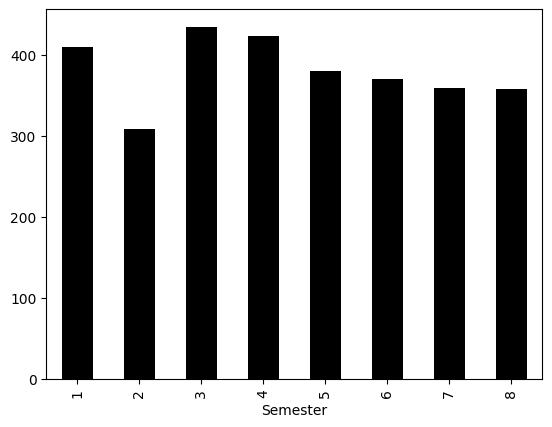

In [14]:
df.groupby('Semester')['CGPA'].sum().plot(kind = 'bar', color = 'black' )

Student Analytics Dashboard

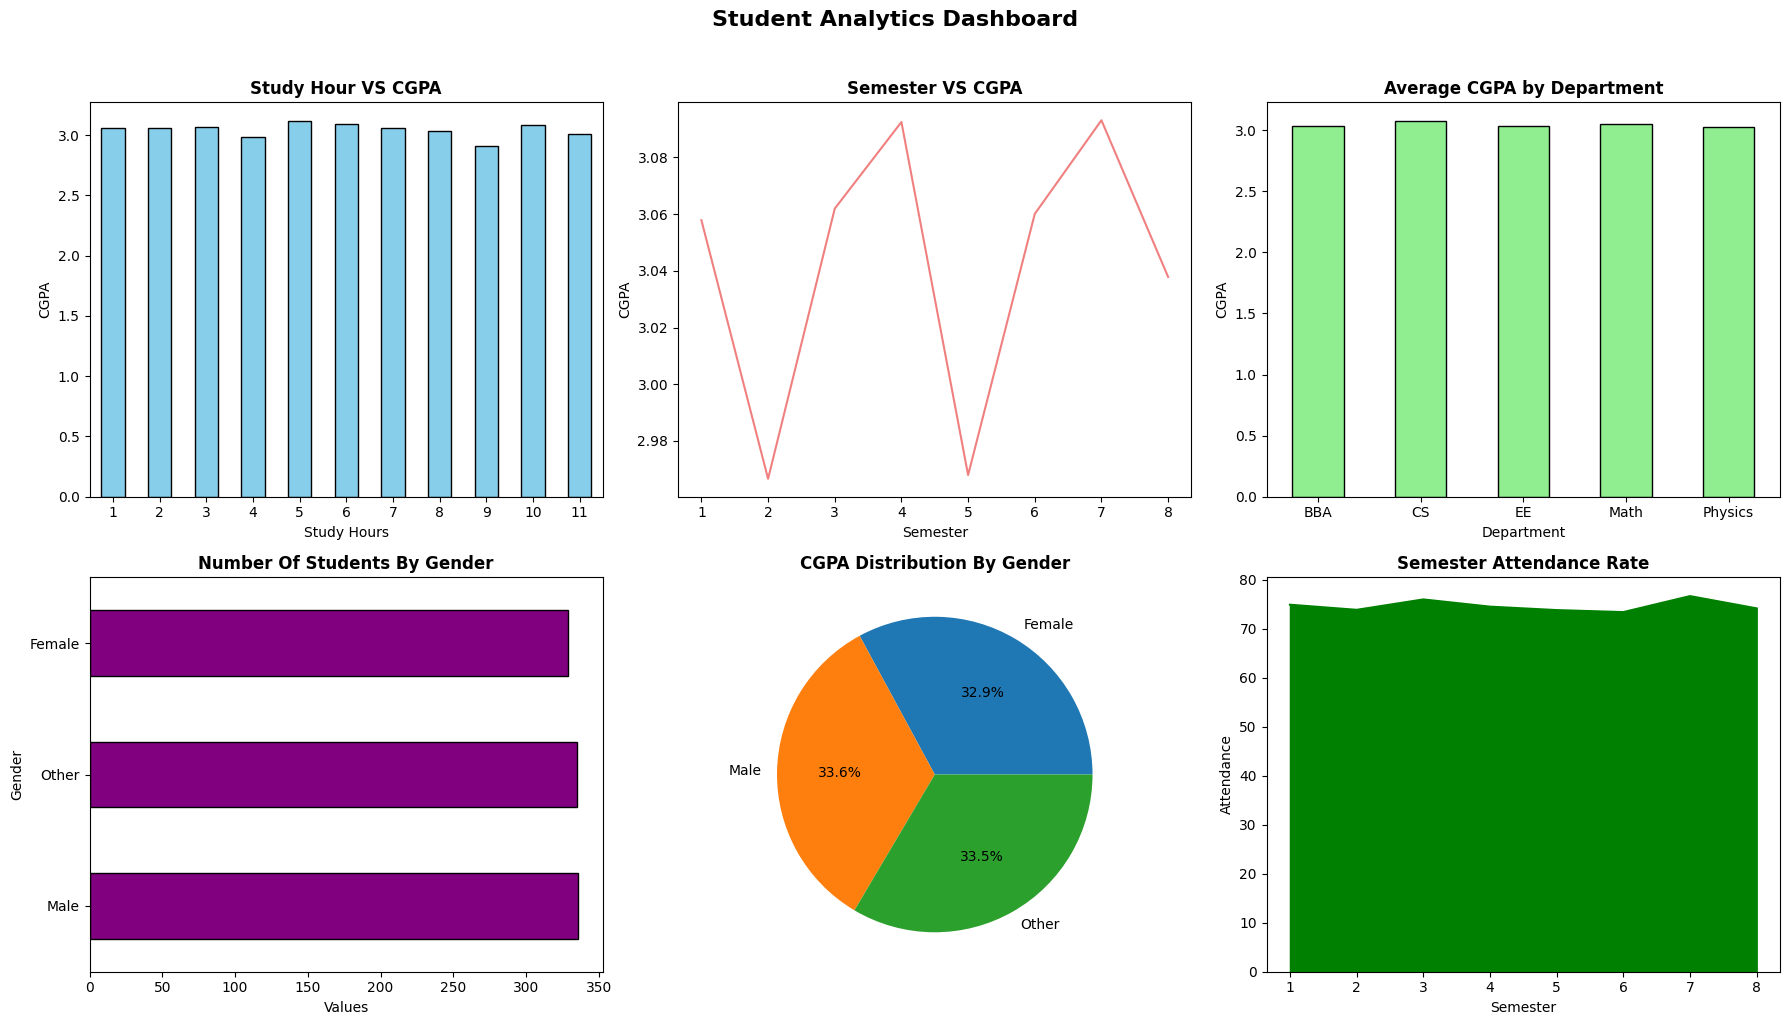

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sty_hur = df.groupby("Study_Hours_Per_Day")["CGPA"].mean().plot(kind='bar', ax=axes[0, 0], color = 'skyblue', edgecolor = 'black')
axes[0, 0].set_title('Study Hour VS CGPA', fontweight = 'bold')
axes[0, 0].set_xlabel('Study Hours')
axes[0, 0].set_ylabel('CGPA')
axes[0, 0].tick_params(axis = 'x', rotation =0)



smes = df.groupby('Semester')['CGPA'].mean().plot(kind='line', ax = axes[0, 1], color = 'lightcoral')
axes[0,1].set_title('Semester VS CGPA', fontweight = 'bold')
axes[0,1].set_xlabel('Semester')
axes[0,1].set_ylabel("CGPA")

dept = df.groupby('Department')['CGPA'].mean().plot(kind='bar',ax = axes[0,2], color = 'lightgreen', edgecolor = 'black' )
axes[0, 2].set_title("Average CGPA by Department", fontweight = 'bold')
axes[0, 2].set_xlabel('Department')
axes[0, 2].set_ylabel('CGPA')
axes[0, 2].tick_params(axis = 'x', rotation =0)

gen = df['Gender'].value_counts().plot(kind = 'barh', ax = axes[1, 0], color = 'purple', edgecolor = 'black')
axes[1, 0].set_title('Number Of Students By Gender', fontweight = 'bold')
axes[1, 0].set_xlabel('Values')
axes[1, 0].set_ylabel('Gender')

cgpa = df.groupby('Gender')['CGPA'].count().plot(kind='pie', ax = axes[1, 1], autopct = '%1.1f%%')
axes[1, 1].set_title("CGPA Distribution By Gender", fontweight = 'bold')

area = df.groupby('Semester')['Attendance_Rate'].mean().plot(kind='area', ax = axes[1, 2], color = 'green')
axes[1, 2].set_title('Semester Attendance Rate', fontweight= 'bold')
axes[1, 2].set_xlabel ('Semester')
axes[1, 2].set_ylabel('Attendance')

plt.suptitle("Student Analytics Dashboard", fontsize = 16, fontweight = 'bold', y = 1.02)
plt.tight_layout()
plt.show()